# AICE Associate 이진분류 실전 모의고사

- 권장 시간: **90분**
- 문항 수: **14문항**
- 데이터 파일: `aice_binary_mock_customer_churn.csv`
- 모든 셀은 위에서부터 순서대로 실행하세요.
- 문제에서 지정한 변수명은 그대로 사용하세요.
- 정답 코드와 힌트는 제공되지 않습니다.

> 목표: 고객의 이탈 위험(`churn_risk`)을 예측하는 이진분류 모델을 구축합니다.


## 응시 전 확인

1. 노트북과 CSV를 같은 폴더에 둡니다.
2. 제한 시간 90분을 설정합니다.
3. 실행하지 않은 셀은 채점 대상이 될 수 없다고 가정합니다.
4. 문제가 요구하지 않은 원본 데이터 수정은 피하세요.


## 문제 1. 데이터 불러오기 및 구조 확인

CSV를 `data`로 불러온 후 다음을 확인하세요.

- 데이터의 행·열 개수
- 처음 5개 행
- 열별 자료형과 결측치 여부
- 수치형 열의 기술통계량
- 열별 결측치 개수
- 완전히 동일한 중복 행 개수
- `churn_risk`의 클래스별 개수와 비율

출력 결과를 보고 타깃이 불균형한지 한 문장으로 판단하세요.


In [62]:
import pandas as pd
import numpy as np

data = pd.read_csv('aice_binary_mock_customer_churn.csv')

data.head()

,customer_id,signup_date,age,gender,region,service_tier,contract_type,payment_method,auto_payment,tenure_months,monthly_fee,support_calls_90d,late_payments_12m,weekly_usage_hours,monthly_usage_minutes,churn_risk
0,CUS-10001,2024-07-24,63.0,Female,Daejeon,Basic,One-year,Card,Yes,60.0,60.8,1.0,0.0,1.1,83.0,No
1,CUS-10002,2022-06-23,35.0,Female,Busan,Basic,Monthly,Bank transfer,No,56.0,57.5,0.0,0.0,6.3,413.0,Yes
2,CUS-10003,2021-07-12,45.0,Male,Seoul,Standard,Monthly,Card,Yes,17.0,65.1,2.0,1.0,4.3,313.0,Yes
3,CUS-10004,2025-08-07,46.0,Male,Seoul,Basic,Two-year,Card,Yes,50.0,63.1,3.0,0.0,12.7,880.0,No
4,CUS-10005,2022-12-27,50.0,Male,Seoul,Basic,Monthly,Card,Yes,32.0,57.9,2.0,0.0,2.1,171.0,No


In [63]:
print(data.info())
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            928 non-null    str    
 1   signup_date            921 non-null    str    
 2   age                    911 non-null    float64
 3   gender                 916 non-null    str    
 4   region                 919 non-null    str    
 5   service_tier           916 non-null    str    
 6   contract_type          928 non-null    str    
 7   payment_method         918 non-null    str    
 8   auto_payment           928 non-null    str    
 9   tenure_months          928 non-null    float64
 10  monthly_fee            915 non-null    float64
 11  support_calls_90d      928 non-null    float64
 12  late_payments_12m      928 non-null    float64
 13  weekly_usage_hours     913 non-null    float64
 14  monthly_usage_minutes  928 non-null    float64
 15  churn_risk       

,age,tenure_months,monthly_fee,support_calls_90d,late_payments_12m,weekly_usage_hours,monthly_usage_minutes
count,911.000000,928.000000,915.000000,928.000000,928.000000,913.000000,928.000000
mean,40.881449,36.257543,57.294754,1.802802,0.793103,5.394414,386.199353
std,11.618439,20.275222,18.825753,1.347383,0.900842,3.489659,249.769771
min,18.000000,1.000000,12.000000,0.000000,0.000000,0.200000,30.000000
25%,33.000000,19.000000,45.100000,1.000000,0.000000,2.900000,209.000000
50%,41.000000,36.000000,57.700000,2.000000,1.000000,4.600000,334.000000
75%,49.000000,53.000000,69.900000,3.000000,1.000000,7.000000,511.500000
max,76.000000,72.000000,116.100000,8.000000,5.000000,22.000000,2600.000000


In [64]:
print(data.isnull().sum())
print(data.duplicated().sum())

customer_id               0
signup_date               7
age                      17
gender                   12
region                    9
service_tier             12
contract_type             0
payment_method           10
auto_payment              0
tenure_months             0
monthly_fee              13
support_calls_90d         0
late_payments_12m         0
weekly_usage_hours       15
monthly_usage_minutes     0
churn_risk                0
dtype: int64
8


In [67]:
print(data['churn_risk'].value_counts())
print(data['churn_risk'].value_counts(normalize=True))

# 출력 결과 타깃이 불균형함을 확인했다

churn_risk
No     825
Yes    103
Name: count, dtype: int64
churn_risk
No     0.889009
Yes    0.110991
Name: proportion, dtype: float64


**판단:**  



## 문제 2. 중복·날짜 처리

`data`에 다음 작업을 순서대로 수행하세요.

1. 완전히 동일한 중복 행을 제거합니다.
2. 기존 인덱스가 열로 남지 않도록 인덱스를 초기화합니다.
3. `signup_date`를 날짜 자료형으로 변환합니다.
4. 날짜가 결측된 행을 제거합니다.
5. 다시 인덱스를 0부터 연속되게 초기화합니다.
6. `signup_date`에서 아래 파생변수를 생성합니다.
   - `signup_year`
   - `signup_month`
   - `signup_dayofweek`
7. 처리 후 데이터 크기, 전체 중복 수, `signup_date`의 자료형을 출력합니다.


In [ ]:
data.drop_duplicates().reset_index(drop=True, inplace=True)

data['signup_date'] = pd.to_datetime(data['signup_date'])

# subset = 해당 컬럼의 na 행을 삭제
data = data.dropna(subset=['signup_date'])

data['signup_year'] = data['signup_date'].dt.year
data['signup_month'] = data['signup_date'].dt.month
data['signup_dayofweek'] = data['signup_date'].dt.day_of_week

print(data.shape)
print(data.duplicated().sum())
print(data['signup_date'].dtypes)

(921, 19)
8
datetime64[us]


## 문제 3. 결측치 처리

다음 기준으로 결측치를 처리하세요.

- `age`, `monthly_fee` → 각 열의 중앙값
- `weekly_usage_hours` → 평균값
- `gender`, `region`, `service_tier`, `payment_method` → 각 열의 최빈값

처리 후 전체 결측치 개수를 출력하세요.


In [70]:
data['age'] = data['age'].fillna(data['age'].median())
data['monthly_fee'] = data['monthly_fee'].fillna(data['monthly_fee'].median())
data['weekly_usage_hours'] =data['weekly_usage_hours'].fillna(data['weekly_usage_hours'].mean())
def mode(col):
  data[col] = data[col].fillna(data[col].mode()[0])

mode('gender')
mode('region')
mode('service_tier')
mode('payment_method')

In [71]:
data.isnull().sum()

customer_id              0
signup_date              0
age                      0
gender                   0
region                   0
service_tier             0
contract_type            0
payment_method           0
auto_payment             0
tenure_months            0
monthly_fee              0
support_calls_90d        0
late_payments_12m        0
weekly_usage_hours       0
monthly_usage_minutes    0
churn_risk               0
signup_year              0
signup_month             0
signup_dayofweek         0
dtype: int64

## 문제 4. 시각화 및 클래스 분포 확인

1. `churn_risk`의 클래스별 개수를 countplot으로 시각화하세요.
2. 제목을 `Churn Risk Distribution`으로 설정하세요.
3. `region`별 `churn_risk` 개수를 하나의 countplot에 표시하세요.
4. x축 눈금을 45도 회전하세요.
5. 그래프를 보고 이 데이터 분할 시 `stratify`가 필요한 이유를 한 문장으로 작성하세요.


([0, 1], [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

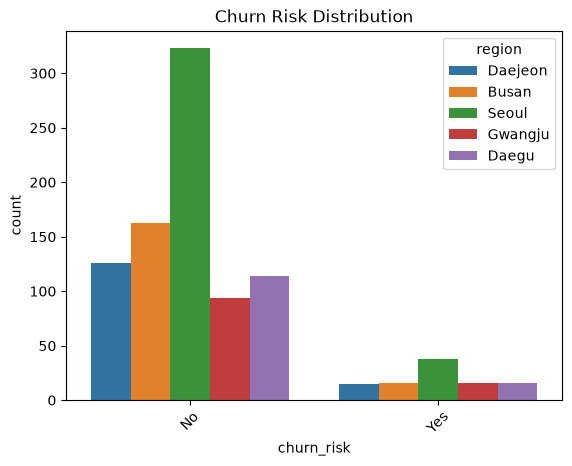

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=data, x='churn_risk', hue='region')

plt.title('Churn Risk Distribution')

plt.xticks(rotation=45)

# stratify 가 필요한 이유 = 데이터 양의 편차가 커서 split 할 때 비율이 맞지 않게 나눠질 가능성이 있다 .
# stratify를 사용하면 원본 데이터의 비율과 가장 비슷하게 만들어준다.


**판단:**  



## 문제 5. 이상치 제거

`monthly_usage_minutes`가 **900 이상인 행**을 이상치로 정의합니다.

1. 이상치 행 개수를 출력하세요.
2. 이상치 행을 제거한 결과를 `data_clean`에 저장하세요.
3. 기존 인덱스가 열로 남지 않게 인덱스를 초기화하세요.
4. 제거 전후 데이터 크기와 제거된 행 개수를 출력하세요.


In [85]:
# 이상치 행 개수
print(data[data['monthly_usage_minutes']>=900].shape[0])
data_clean = data.drop(data[data['monthly_usage_minutes']>=900].index, axis=0).reset_index(drop=True)
print(data.shape[0])
print(data_clean.shape[0])

6
921
915


## 문제 6. 범주형 인코딩

`data_clean`을 복사하여 `data_model`을 만드세요.

1. `auto_payment`: `No → 0`, `Yes → 1`로 변환합니다.
2. `gender`: `Female → 0`, `Male → 1`로 변환합니다.
3. `churn_risk`는 `LabelEncoder`로 변환하고, 전용 인코더 이름은 `target_encoder`로 지정합니다.
4. `target_encoder.classes_`를 출력하여 0과 1에 대응하는 원래 값을 확인합니다.
5. 아래 명목형 열은 첫 범주를 제거하지 않고 원-핫 인코딩하며, 생성 열은 정수형으로 지정합니다.

```python
categorical_columns = ['region', 'service_tier', 'contract_type', 'payment_method']
```


In [87]:
from sklearn.preprocessing import LabelEncoder

data_model = data_clean.copy()

data_model['auto_payment'] = data_model['auto_payment'].map({
  'No':0,
  'Yes':1
})

data_model['gender'] = data_model['gender'].map({
  'Male':0,
  'Female':1
})

target_encoder = LabelEncoder()

data_model['churn_risk'] = target_encoder.fit_transform(data_model['churn_risk'])

print(target_encoder.classes_)

categorical_columns = ['region', 'service_tier', 'contract_type', 'payment_method']

data_model = pd.get_dummies(data_model, columns=categorical_columns, dtype=int)


['No' 'Yes']


## 문제 7. 독립변수와 타깃 분리

1. 모델 학습에 사용하지 않을 `customer_id`, `signup_date`를 제거하세요.
2. 타깃은 `churn_risk`입니다.
3. 독립변수는 `X`, 타깃은 `y`에 저장하세요.
4. `X.shape`, `y.shape`, `X.dtypes`, `y.value_counts(normalize=True)`를 출력하세요.
5. `customer_id`와 원본 날짜 열을 제외한 이유를 각각 한 문장으로 작성하세요.


In [89]:
X = data_model.drop(columns=['customer_id', 'signup_date', 'churn_risk'])
y = data_model['churn_risk']

print(X.shape, y.shape, X.dtypes, y.value_counts(normalize=True))

# id 와 원본 날짜 열을 제외한 이유는 실제 통계 상황에서 필요하지 않기 때문이고, 날짜 열 제거한 이유는 중복되는 정보의 컬럼들이 존재하기 때문이다.

(915, 27) (915,) age                               float64
gender                              int64
auto_payment                        int64
tenure_months                     float64
monthly_fee                       float64
support_calls_90d                 float64
late_payments_12m                 float64
weekly_usage_hours                float64
monthly_usage_minutes             float64
signup_year                         int32
signup_month                        int32
signup_dayofweek                    int32
region_Busan                        int64
region_Daegu                        int64
region_Daejeon                      int64
region_Gwangju                      int64
region_Seoul                        int64
service_tier_Basic                  int64
service_tier_Premium                int64
service_tier_Standard               int64
contract_type_Monthly               int64
contract_type_One-year              int64
contract_type_Two-year              int64
payment_method_Ba

**판단:**  



## 문제 8. 학습/테스트 분할과 스케일링

1. 전체 데이터의 20%를 테스트 데이터로 분리하세요.
2. `random_state=42`를 사용하세요.
3. 원본 클래스 비율이 유지되도록 설정하세요.
4. `StandardScaler`를 사용하세요.
5. 훈련 데이터로만 스케일러를 학습하고, 테스트 데이터에는 같은 기준을 적용하세요.
6. 아래 변수명을 사용하세요.

```python
X_train, X_test, y_train, y_test
X_train_scaled, X_test_scaled
```

분할된 데이터 크기와 `y_train`, `y_test`의 클래스 비율을 출력하세요.


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

churn_risk
0    0.889344
1    0.110656
Name: proportion, dtype: float64
churn_risk
0    0.89071
1    0.10929
Name: proportion, dtype: float64


## 문제 9. 기본 LogisticRegression 평가

1. `random_state=42`인 `LogisticRegression`을 `logistic_model`로 생성하고 학습하세요.
2. 테스트 데이터의 예측 클래스는 `y_pred`, 클래스 1의 확률은 `y_proba`에 저장하세요.
3. 혼동행렬과 `classification_report`를 출력하세요.
4. 확률값을 사용해 ROC-AUC를 계산하세요.
5. 정확도만으로 이 모델을 좋은 모델이라고 판단할 수 있는지 결과를 근거로 작성하세요.


**판단:**  



## 문제 10. 임계값 조정

1. `y_proba`에 임계값 `0.35`를 적용하여 `y_pred_035`를 생성하세요.
2. 결과는 정수형이어야 합니다.
3. 혼동행렬과 `classification_report`를 출력하세요.
4. 기본 임계값 결과와 비교하여 클래스 1의 Precision, Recall, F1 변화를 작성하세요.


**판단:**  



## 문제 11. 클래스 가중치 적용

1. `class_weight='balanced'`, `random_state=42`인 LogisticRegression을 `balanced_model`로 생성하세요.
2. 학습 후 예측 결과를 `y_pred_balanced`에 저장하세요.
3. 혼동행렬과 `classification_report`를 출력하세요.
4. 기본 모델과 비교해 클래스 1의 Recall이 어떻게 변했는지 작성하세요.
5. `class_weight='balanced'`가 데이터를 직접 복제하는지, 학습 영향력을 조정하는지 작성하세요.


**판단:**  



## 문제 12. 트리 계열 모델 비교

스케일링 전 데이터를 사용하여 다음 두 모델을 학습하세요.

- `DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)`
- `RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)`

각 모델의 예측값을 서로 다른 변수에 저장하고, 클래스 1의 Recall과 F1-score만 출력하세요. Balanced LogisticRegression까지 포함해 이탈 탐지에 사용할 모델 하나를 선택하고 이유를 작성하세요.


**선택 및 이유:**  



## 문제 13. 교차검증

`cross_val_score()`를 사용하여 다음 세 모델을 5겹 교차검증하세요. 평가 기준은 `recall`입니다.

- Balanced LogisticRegression: 스케일링된 훈련 데이터 사용
- Balanced DecisionTree: 스케일링 전 훈련 데이터 사용
- Balanced RandomForest: 스케일링 전 훈련 데이터 사용

각 모델의 5개 점수와 평균을 출력하고, 테스트셋 한 번의 평가와 비교해 최종 모델을 선택하세요.


**최종 선택:**  



## 문제 14. TensorFlow 이진분류

다음 구조의 신경망을 `binary_model`로 만드세요.

- 입력: 훈련 데이터의 특성 개수
- Dense 64, `relu`
- Dropout 0.2
- Dense 32, `relu`
- 출력 노드 1개, 이진분류에 적절한 활성화 함수

컴파일 및 학습 조건:

- optimizer: `adam`
- 이진분류에 적절한 loss
- metrics: `accuracy`
- EarlyStopping: `val_loss`, patience 8, 최적 가중치 복원
- ModelCheckpoint: `best_binary_mock.keras`, `val_loss`, 최적 모델만 저장
- `validation_split=0.2`
- epochs 80, batch_size 32
- 테스트 데이터는 검증 데이터로 사용하지 않습니다.

학습 후 다음을 수행하세요.

1. 실제 실행된 epoch 수를 출력합니다.
2. `loss`와 `val_loss`를 하나의 그래프로 표시합니다.
3. 테스트 데이터의 예측 확률을 1차원 배열로 변환합니다.
4. 임계값 0.5를 적용한 정수형 예측값을 생성합니다.
5. 혼동행렬, `classification_report`, ROC-AUC를 출력합니다.
6. 그래프에서 과적합 여부와 모델의 클래스 1 탐지 성능을 짧게 판단합니다.


**최종 판단:**  



---

## 제출 전 점검

- 모든 코드 셀을 실행했는가?
- 지정된 변수명을 사용했는가?
- 출력값과 판단 문장을 남겼는가?
- 오류가 남은 셀이 없는가?
- 노트북을 저장했는가?
